# Sobel-based Watermark Detection


In [17]:
!pip install -q opencv-python matplotlib numpy pillow


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

EPS = 1e-6


## Dataset download (Kaggle)


In [19]:
import kagglehub
import glob
import os

print("Downloading Kaggle dataset...")
try:
    ds_path = kagglehub.dataset_download("felicepollano/watermarked-not-watermarked-images")
    print(f"✓ Dataset downloaded to: {ds_path}")

    DATASET_ROOT = Path(ds_path) / "wm-nowm"
    print(f"Dataset root: {DATASET_ROOT}")

    watermarked_dir = DATASET_ROOT / "train" / "watermark"
    clean_dir = DATASET_ROOT / "train" / "no-watermark"

    print("\n=== Path Verification ===")
    print(f"Dataset root: {DATASET_ROOT}")
    print(f"  - Exists: {DATASET_ROOT.exists()}")
    print(f"Watermarked dir: {watermarked_dir}")
    print(f"  - Exists: {watermarked_dir.exists()}")
    print(f"Clean dir: {clean_dir}")
    print(f"  - Exists: {clean_dir.exists()}")

    if watermarked_dir.exists():
        all_wm_images = glob.glob(os.path.join(watermarked_dir.as_posix(), "*.*"))
        print(f"  - Watermarked images: {len(all_wm_images):,}")
        if len(all_wm_images) > 0:
            print(f"    Example: {os.path.basename(all_wm_images[0])}")

    if clean_dir.exists():
        all_no_wm_images = glob.glob(os.path.join(clean_dir.as_posix(), "*.*"))
        print(f"  - Clean images: {len(all_no_wm_images):,}")
        if len(all_no_wm_images) > 0:
            print(f"    Example: {os.path.basename(all_no_wm_images[0])}")

    if not watermarked_dir.exists() or not clean_dir.exists():
        raise ValueError(
            f"Required directories not found.\n"
            f"Watermarked: {watermarked_dir.exists()}\n"
            f"Clean: {clean_dir.exists()}"
        )
except Exception as e:
    print(f"Dataset download failed: {e}")
    print("Alternative: manually upload the dataset or set the path directly.")
    raise


Using Colab cache for faster access to the 'watermarked-not-watermarked-images' dataset.
✓ Dataset downloaded to: /kaggle/input/watermarked-not-watermarked-images
Dataset root: /kaggle/input/watermarked-not-watermarked-images/wm-nowm

=== Path Verification ===
Dataset root: /kaggle/input/watermarked-not-watermarked-images/wm-nowm
  - Exists: True
Watermarked dir: /kaggle/input/watermarked-not-watermarked-images/wm-nowm/train/watermark
  - Exists: True
Clean dir: /kaggle/input/watermarked-not-watermarked-images/wm-nowm/train/no-watermark
  - Exists: True
  - Watermarked images: 12,510
    Example: pexels-photo-776832.jpeg
  - Clean images: 12,477
    Example: pexels-photo-1202481.jpeg


## WatermarkDetector


In [20]:
class WatermarkDetector:
    """
    Lightweight Sobel-based watermark candidate detector (no CNN).
    Pipeline: CLAHE pre-processing → Sobel → band/orientation masks → candidate boxes.
    """

    def __init__(
        self,
        sobel_ksize=3,
        p_low=8,
        p_high=80,
        tile_rows=4,
        tile_cols=6,
        tile_p_low=7,
        tile_p_high=70,
        border_frac=0.33,
        horiz_deg=23,
        max_boxes=1,
    ):
        self.sobel_ksize = sobel_ksize
        self.p_low, self.p_high = p_low, p_high
        self.tile_rows, self.tile_cols = tile_rows, tile_cols
        self.tile_p_low, self.tile_p_high = tile_p_low, tile_p_high
        self.border_frac = border_frac
        self.horiz_deg = horiz_deg
        self.max_boxes = max_boxes

    def preprocess_image(self, image: np.ndarray) -> np.ndarray:
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        L = lab[:, :, 0]
        clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
        return clahe.apply(L)

    def apply_sobel(self, image: np.ndarray):
        gx = cv2.Sobel(image, cv2.CV_32F, 1, 0, ksize=self.sobel_ksize)
        gy = cv2.Sobel(image, cv2.CV_32F, 0, 1, ksize=self.sobel_ksize)
        mag = cv2.magnitude(gx, gy)
        ang = cv2.phase(gx, gy, angleInDegrees=False)
        return (mag, ang,
                cv2.convertScaleAbs(gx),
                cv2.convertScaleAbs(gy),
                cv2.convertScaleAbs(mag))

    def _band_from_percentiles(self, mag: np.ndarray, lo: float, hi: float) -> np.ndarray:
        flat = mag.reshape(-1)
        nz = flat[flat > 0]
        if nz.size < 100:
            a, b = 4.0, 50.0
        else:
            a = np.percentile(nz, lo)
            b = np.percentile(nz, hi)
        band = ((mag >= a) & (mag <= b)).astype(np.uint8) * 255
        band = cv2.dilate(band, cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2)), 1)
        return band

    def _tile_adaptive_band(self, mag: np.ndarray) -> np.ndarray:
        H, W = mag.shape
        rh, cw = H // self.tile_rows, W // self.tile_cols
        out = np.zeros_like(mag, dtype=np.uint8)
        for r in range(self.tile_rows):
            for c in range(self.tile_cols):
                y0, y1 = r * rh, H if r == self.tile_rows - 1 else (r + 1) * rh
                x0, x1 = c * cw, W if c == self.tile_cols - 1 else (c + 1) * cw
                tile = mag[y0:y1, x0:x1]
                band = self._band_from_percentiles(tile, self.tile_p_low, self.tile_p_high)
                out[y0:y1, x0:x1] = band
        out = cv2.medianBlur(out, 3)
        return out

    def _border_band(self, mag: np.ndarray) -> np.ndarray:
        H, W = mag.shape
        t = int(self.border_frac * H)
        l = int(self.border_frac * W)
        band = np.zeros_like(mag, dtype=np.uint8)
        band[:t, :] = self._band_from_percentiles(mag[:t, :], 4, 70)
        band[H - t:, :] = self._band_from_percentiles(mag[H - t:, :], 4, 70)
        band[:, :l] = cv2.max(band[:, :l], self._band_from_percentiles(mag[:, :l], 4, 70))
        band[:, W - l:] = cv2.max(band[:, W - l:], self._band_from_percentiles(mag[:, W - l:], 4, 70))
        band = cv2.morphologyEx(band, cv2.MORPH_CLOSE,
                                cv2.getStructuringElement(cv2.MORPH_RECT, (21, 3)), 2)
        return band

    def _orientation_text_mask(self, mag: np.ndarray, ang: np.ndarray) -> np.ndarray:
        theta = (ang + np.pi) % (2 * np.pi) - np.pi
        deg = np.abs(theta) * 180.0 / np.pi
        horiz = (deg <= self.horiz_deg) | (deg >= 180 - self.horiz_deg)
        vert = (deg >= 90 - self.horiz_deg) & (deg <= 90 + self.horiz_deg)

        mag_n = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        _, sig = cv2.threshold(mag_n, 28, 255, cv2.THRESH_BINARY)

        mh = (horiz.astype(np.uint8) * 255) & sig
        mv = (vert.astype(np.uint8) * 255) & sig

        mask = cv2.addWeighted(mh, 1.0, mv, 0.3, 0)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE,
                                cv2.getStructuringElement(cv2.MORPH_RECT, (17, 1)), 2)
        return mask

    def _combine_and_clean(self, band_global, band_tile, band_border, orient):
        weak_all = cv2.bitwise_or(band_global, cv2.bitwise_or(band_tile, band_border))
        combined = cv2.bitwise_and(weak_all, orient)

        combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN,
                                    cv2.getStructuringElement(cv2.MORPH_RECT, (1, 5)), 1)
        combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE,
                                    cv2.getStructuringElement(cv2.MORPH_RECT, (23, 3)), 2)
        combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN,
                                    cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)), 1)
        return combined

    def _bottom_band_fallback(self, combined):
        H, W = combined.shape
        band_h = int(0.22 * H)
        y0 = H - band_h
        strip = combined[y0:, :]
        col_density = np.mean(strip == 255, axis=0)
        active = col_density > 0.04
        if not active.any():
            return []
        boxes = []
        start = None
        for x in range(W):
            if active[x] and start is None:
                start = x
            elif not active[x] and start is not None:
                if x - start > 0.15 * W:
                    boxes.append((start, y0, x - start, band_h))
                start = None
        if start is not None and W - start > 0.15 * W:
            boxes.append((start, y0, W - start, band_h))
        return boxes

    def _score_boxes(self, boxes, mask, mag):
        if boxes is None or len(boxes) == 0:
            return np.array([], dtype=np.float32)

        H, W = mask.shape
        mag_n = cv2.normalize(mag, None, 0, 1, cv2.NORM_MINMAX)
        scores = []
        for (x, y, bw, bh) in boxes:
            roi_m = mask[y:y+bh, x:x+bw]
            roi_g = mag_n[y:y+bh, x:x+bw]
            if roi_m.size == 0:
                scores.append(0.0)
                continue
            fill = np.mean(roi_m == 255)
            strength = np.mean(roi_g[roi_m == 255]) if np.any(roi_m == 255) else 0.0
            proj = np.sum(roi_m == 255, axis=1) / (bw + EPS)
            bandiness = np.mean((proj > 0.10).astype(np.float32))
            border = min(x, y, W - (x + bw), H - (y + bh))
            border_prior = np.clip(1.0 - (border / max(1, min(H, W) * 0.40)), 0.0, 1.0) * 0.40
            scores.append(float(0.45 * fill + 0.20 * strength + 0.35 * bandiness + border_prior))
        return np.array(scores, dtype=np.float32)

    def _extract_text_lines(self, mask, gray, mag):
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        H, W = gray.shape
        cand = []
        for c in contours:
            x, y, bw, bh = cv2.boundingRect(c)
            area = bw * bh
            if area < 600 or area > H * W * 0.90:
                continue
            ar = bw / float(bh)
            if ar < 1.1 and not (bh >= 12 and 0.6 <= ar <= 2.5):
                continue
            if bh < 6 or bh > int(0.50 * H):
                continue
            sol = cv2.contourArea(c) / (area + EPS)
            if sol < 0.20:
                continue
            if np.mean(mask[y:y+bh, x:x+bw] == 255) < 0.025:
                continue
            pad_x = int(0.02 * W)
            pad_y = int(0.02 * H)
            x = max(0, x - pad_x)
            y = max(0, y - pad_y)
            bw = min(W - x, bw + 2 * pad_x)
            bh = min(H - y, bh + 2 * pad_y)
            cand.append((x, y, bw, bh))

        if not cand:
            return []

        scores = self._score_boxes(cand, mask, mag)
        cand_arr = np.array(cand)
        order = np.argsort(-scores)
        cand_arr = cand_arr[order].tolist()
        cand_arr = self._nms(cand_arr, 0.40)
        return cand_arr[: self.max_boxes]

    def _nms(self, boxes, iou_thresh=0.45):
        if not boxes:
            return []
        B = np.array(boxes, dtype=np.float32)
        x1, y1 = B[:, 0], B[:, 1]
        x2, y2 = B[:, 0] + B[:, 2], B[:, 1] + B[:, 3]
        areas = (x2 - x1) * (y2 - y1)
        order = np.argsort(-areas)
        keep = []
        while order.size:
            i = order[0]
            keep.append(i)
            xx1 = np.maximum(x1[i], x1[order[1:]])
            yy1 = np.maximum(y1[i], y1[order[1:]])
            xx2 = np.minimum(x2[i], x2[order[1:]])
            yy2 = np.minimum(y2[i], y2[order[1:]])
            w = np.maximum(0, xx2 - xx1)
            h = np.maximum(0, yy2 - yy1)
            inter = w * h
            iou = inter / (areas[i] + areas[order[1:]] - inter + EPS)
            order = order[1:][iou <= iou_thresh]
        return [tuple(map(int, B[i])) for i in keep]

    def detect_watermark_with_sobel(self, image: np.ndarray):
        gray = self.preprocess_image(image)
        mag, ang, gx_vis, gy_vis, mag_vis = self.apply_sobel(gray)
        band_global = self._band_from_percentiles(mag, self.p_low, self.p_high)
        band_tile = self._tile_adaptive_band(mag)
        band_border = self._border_band(mag)
        orient = self._orientation_text_mask(mag, ang)
        combined = self._combine_and_clean(band_global, band_tile, band_border, orient)
        boxes = self._extract_text_lines(combined, gray, mag)
        if not boxes:
            fallback_boxes = self._bottom_band_fallback(combined)
            if fallback_boxes:
                boxes = fallback_boxes
        return {
            "gray": gray,
            "sobel_x": gx_vis,
            "sobel_y": gy_vis,
            "magnitude": mag_vis,
            "global_band": band_global,
            "tile_adaptive_mask": band_tile,
            "border_band": band_border,
            "orientation_filter": orient,
            "combined_mask": combined,
            "boxes": boxes,
        }

    def detect(self, image_path: Path):
        image = cv2.imread(str(image_path))
        if image is None:
            raise ValueError(f"Could not load image: {image_path}")
        d = self.detect_watermark_with_sobel(image)
        return {
            'original': image,
            'gray': d['gray'],
            'sobel_x': d['sobel_x'],
            'sobel_y': d['sobel_y'],
            'sobel_magnitude': d['magnitude'],
            'preprocessed': d['gray'],
            'global_band': d['global_band'],
            'tile_adaptive': d['tile_adaptive_mask'],
            'border_band': d['border_band'],
            'orientation_filter': d['orientation_filter'],
            'combined_mask': d['combined_mask'],
            'bounding_boxes': d['boxes'],
        }

    def visualize_results(self, results, save_path=None):
        fig = plt.figure(figsize=(10, 8))

        ax1 = plt.subplot(3, 3, 1)
        ax1.imshow(cv2.cvtColor(results['original'], cv2.COLOR_BGR2RGB))
        ax1.set_title('1. Original Image', fontsize=9, fontweight='bold')
        ax1.axis('off')

        ax2 = plt.subplot(3, 3, 2)
        ax2.imshow(results['preprocessed'], cmap='gray')
        ax2.set_title('2. Preprocessed (CLAHE)', fontsize=9)
        ax2.axis('off')

        ax3 = plt.subplot(3, 3, 3)
        ax3.imshow(results['sobel_magnitude'], cmap='gray')
        ax3.set_title('3. Sobel Magnitude', fontsize=9)
        ax3.axis('off')

        ax4 = plt.subplot(3, 3, 4)
        ax4.imshow(results['global_band'], cmap='gray')
        ax4.set_title('4. Global Band', fontsize=9)
        ax4.axis('off')

        ax5 = plt.subplot(3, 3, 5)
        ax5.imshow(results['tile_adaptive'], cmap='gray')
        ax5.set_title('5. Tile-Adaptive Band', fontsize=9)
        ax5.axis('off')

        ax6 = plt.subplot(3, 3, 6)
        ax6.imshow(results['border_band'], cmap='gray')
        ax6.set_title('6. Border Band', fontsize=9)
        ax6.axis('off')

        ax7 = plt.subplot(3, 3, 7)
        ax7.imshow(results['orientation_filter'], cmap='gray')
        ax7.set_title('7. Orientation Filter', fontsize=9)
        ax7.axis('off')

        ax8 = plt.subplot(3, 3, 8)
        ax8.imshow(results['combined_mask'], cmap='gray')
        ax8.set_title('8. Combined Mask', fontsize=9, fontweight='bold')
        ax8.axis('off')

        ax9 = plt.subplot(3, 3, 9)
        vis = results['original'].copy()
        for (x, y, w, h) in results['bounding_boxes']:
            cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 3)
            cv2.putText(vis, 'WATERMARK', (x, max(0, y - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        ax9.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax9.set_title(
            '9. Final Result\n' + ('✓ DETECTED' if results['bounding_boxes'] else '✗ NOT DETECTED'),
            fontsize=9,
            fontweight='bold',
            color=('green' if results['bounding_boxes'] else 'red')
        )
        ax9.axis('off')

        plt.tight_layout(pad=1.5)
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()


print("WatermarkDetector (Sobel only) is ready!")


WatermarkDetector (Sobel only) is ready!


## Single-image detection & visualization (9-panel)


In [21]:
detector = WatermarkDetector()


def detect_and_visualize(image_path: Path, save_path: Path | None = None):
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    results = detector.detect(image_path)
    detector.visualize_results(results, save_path=save_path)
    return results



Using sample image: /kaggle/input/watermarked-not-watermarked-images/wm-nowm/train/watermark/pexels-photo-776832.jpeg


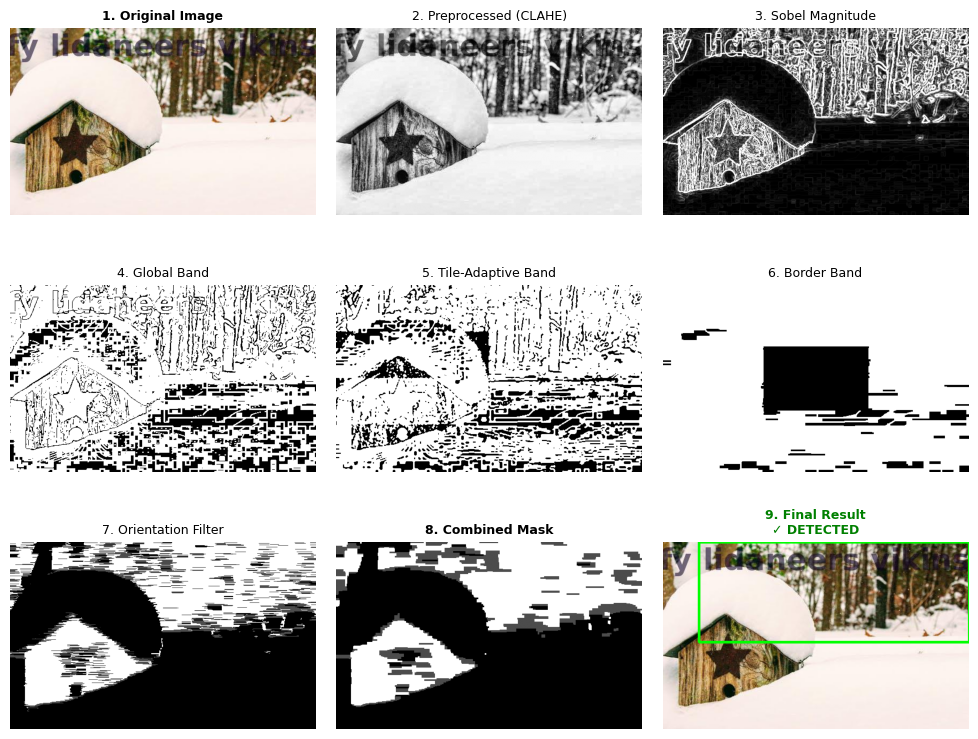

Detected boxes: [(67, 0, 505, 187)]


In [22]:
# Use first Kaggle watermark image for demo
sample_images = list(watermarked_dir.glob("*.*"))
if sample_images:
    image_path = sample_images[0]
    print(f"Using sample image: {image_path}")
    results = detect_and_visualize(image_path)
    print(f"Detected boxes: {results['bounding_boxes'] if 'bounding_boxes' in results else results['boxes']}")
else:
    print("No watermark images found in Kaggle dataset. Run the download cell or set image_path manually.")


## Evaluation helpers (Sobel only)


In [23]:
def box_to_mask(boxes, H, W):
    mask = np.zeros((H, W), dtype=np.uint8)
    for (x, y, w, h) in boxes:
        x, y, w, h = int(x), int(y), int(w), int(h)
        x2, y2 = min(W, x + w), min(H, y + h)
        x, y = max(0, x), max(0, y)
        mask[y:y2, x:x2] = 255
    return mask


def calculate_metrics(pred_mask, gt_mask):
    pred_binary = (pred_mask > 127).astype(np.uint8)
    gt_binary = (gt_mask > 127).astype(np.uint8)

    intersection = np.logical_and(pred_binary, gt_binary).sum()
    union = np.logical_or(pred_binary, gt_binary).sum()

    tp = intersection
    fp = (pred_binary & ~gt_binary).sum()
    fn = (gt_binary & ~pred_binary).sum()
    tn = ((~pred_binary) & (~gt_binary)).sum()

    precision = tp / (tp + fp + EPS)
    recall = tp / (tp + fn + EPS)
    f1 = 2 * (precision * recall) / (precision + recall + EPS)
    iou = intersection / (union + EPS)
    pixel_acc = (pred_binary == gt_binary).sum() / pred_binary.size

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'iou': iou,
        'pixel_accuracy': pixel_acc,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
    }


def calculate_classification_metrics(tp, fp, fn, tn):
    accuracy = (tp + tn) / (tp + fp + fn + tn + EPS)
    precision = tp / (tp + fp + EPS)
    recall = tp / (tp + fn + EPS)
    specificity = tn / (tn + fp + EPS)
    f1 = 2 * (precision * recall) / (precision + recall + EPS)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
    }


def evaluate_dataset(detector, image_dir, negative_image_dir=None, gt_dir=None, max_images=None, save_results_dir=None):
    image_dir = Path(image_dir)
    negative_image_dir = Path(negative_image_dir) if negative_image_dir else None
    if gt_dir:
        gt_dir = Path(gt_dir)

    image_exts = ['.jpg', '.jpeg', '.png', '.bmp']

    def list_images(root):
        out = []
        for ext in image_exts:
            out.extend(root.glob(f'*{ext}'))
            out.extend(root.glob(f'*{ext.upper()}'))
        return out

    positives = list_images(image_dir)
    negatives = list_images(negative_image_dir) if negative_image_dir and negative_image_dir.exists() else []

    if max_images:
        positives = positives[:max_images]
        negatives = negatives[:max_images] if negatives else negatives

    all_images = [(p, 1) for p in positives] + [(n, 0) for n in negatives]
    if not all_images:
        print(f"No images found in {image_dir}")
        return None

    if save_results_dir:
        save_results_dir = Path(save_results_dir)
        save_results_dir.mkdir(parents=True, exist_ok=True)
        det_dir = save_results_dir / "detected"
        miss_dir = save_results_dir / "missed"
        fp_dir = save_results_dir / "false_positive"
        tn_dir = save_results_dir / "true_negative"
        for d in [det_dir, miss_dir, fp_dir, tn_dir]:
            d.mkdir(exist_ok=True)

    tp = fp = fn = tn = 0
    detection_flags = []

    pixel_metrics = [] if gt_dir else None

    for img_path, true_label in all_images:
        image = cv2.imread(str(img_path))
        if image is None:
            print(f"Failed to load {img_path}")
            continue

        H, W = image.shape[:2]

        results = detector.detect(img_path)
        pred_boxes = results['bounding_boxes']
        pred_mask = box_to_mask(pred_boxes, H, W)
        pred_label = 1 if len(pred_boxes) > 0 else 0

        if true_label == 1 and pred_label == 1:
            tp += 1
        elif true_label == 0 and pred_label == 1:
            fp += 1
        elif true_label == 1 and pred_label == 0:
            fn += 1
        elif true_label == 0 and pred_label == 0:
            tn += 1

        detection_flags.append(1.0 if pred_label == 1 else 0.0)

        if save_results_dir:
            vis = image.copy()
            if pred_boxes:
                for (x, y, w, h) in pred_boxes:
                    cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 3)
                    cv2.putText(vis, f'Box: ({x},{y},{w},{h})', (x, max(0, y - 10)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            if true_label == 1:
                save_path = (save_results_dir / "detected" if pred_label else save_results_dir / "missed") / f"{img_path.stem}.jpg"
            else:
                save_path = (save_results_dir / "false_positive" if pred_label else save_results_dir / "true_negative") / f"{img_path.stem}.jpg"
            cv2.imwrite(str(save_path), vis)

        if gt_dir:
            gt_mask = None
            for ext in ['.png', '.jpg', '.jpeg', '.txt']:
                candidate = gt_dir / f"{img_path.stem}{ext}"
                if candidate.exists() and candidate != img_path:
                    if ext == '.txt':
                        boxes = []
                        with open(candidate, 'r') as f:
                            for line in f:
                                parts = line.strip().split()
                                if len(parts) >= 4:
                                    x, y, w, h = map(float, parts[:4])
                                    boxes.append((x, y, w, h))
                        gt_mask = box_to_mask(boxes, H, W)
                    else:
                        gt_img = cv2.imread(str(candidate), cv2.IMREAD_GRAYSCALE)
                        if gt_img is not None:
                            if gt_img.shape != (H, W):
                                gt_img = cv2.resize(gt_img, (W, H))
                            gt_mask = gt_img
                    if gt_mask is not None:
                        break
            if gt_mask is not None:
                metrics = calculate_metrics(pred_mask, gt_mask)
                pixel_metrics.append(metrics)

    classification = calculate_classification_metrics(tp, fp, fn, tn)
    stats = {
        'classification': classification,
        'detection_rate': {'mean': float(np.mean(detection_flags)), 'std': float(np.std(detection_flags))},
    }

    if pixel_metrics:
        for key in ['precision', 'recall', 'f1', 'iou', 'pixel_accuracy']:
            vals = [m[key] for m in pixel_metrics]
            stats[key] = {'mean': float(np.mean(vals)), 'std': float(np.std(vals))}

    return stats


## Quick evaluation on Kaggle sample


In [25]:
max_eval = None
stats = evaluate_dataset(
    detector,
    image_dir=watermarked_dir,
    negative_image_dir=clean_dir,
    gt_dir=None,
    max_images=max_eval,
    save_results_dir=None,
)
if stats:
    print("=== Classification (combined) ===")
    cls = stats['classification']
    print(f"Accuracy     : {cls['accuracy']:.4f} ({cls['accuracy']*100:.2f}%)")
    print(f"Precision    : {cls['precision']:.4f} ({cls['precision']*100:.2f}%)")
    print(f"Recall       : {cls['recall']:.4f} ({cls['recall']*100:.2f}%)")
    print(f"Specificity  : {cls['specificity']:.4f} ({cls['specificity']*100:.2f}%)")
    print(f"F1-score     : {cls['f1']:.4f} ({cls['f1']*100:.2f}%)")
    print(f"TP/FP/FN/TN  : {cls['tp']}/{cls['fp']}/{cls['fn']}/{cls['tn']}")
    print()
    print("=== Detection rate ===")
    print(f"Mean: {stats['detection_rate']['mean']:.4f}  Std: {stats['detection_rate']['std']:.4f}")
else:
    print("Evaluation failed or no images found.")


=== Classification (combined) ===
Accuracy     : 0.5220 (52.20%)
Precision    : 0.5119 (51.19%)
Recall       : 0.9734 (97.34%)
Specificity  : 0.0695 (6.95%)
F1-score     : 0.6710 (67.10%)
TP/FP/FN/TN  : 12177/11610/333/867

=== Detection rate ===
Mean: 0.9520  Std: 0.2138
